## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.

Original evalscript: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/fapar/

Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)  

Conversion: Development Seed (openEO-UDP project)

# The Fraction of Absorbed Photosynthetically Active Radiation (FAPAR) with OpenEO

This notebook demonstrates the calculation of FAPAR using Sentinel-2 imagery with the OpenEO API.

## Overview

In this notebook, we will:
1. Connect to an OpenEO backend service
2. Define an area of interest containing vegetated areas, such as plantation, forest, cropland
3. Load Sentinel-2 L2A imagery for a specific date
4. Calculate and visualize the FAPAR algorithm
5. Export results for further analysis

## What is Fraction of Absorbed Photosynthetically Active Radiation (FAPAR)?

FAPAR is a dimensionless fraction (0–1) that quantifies the proportion of incoming solar radiation in the photosynthetically active range (400–700 nm) absorbed by live green vegetation. Following the methodology in [Evalscript's FAPAR](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/fapar/), this notebook implements a neural network ported from SNAP trained on Sentinel-2 data.

### Applications

- Vegetation health and stress monitoring as FAPAR captures how efficiently canopies intercept light for photosynthesis
- Crop productivity and yield forecasting as FAPAR is a direct input to light-use efficiency models
- Carbon and energy flux estimation as FAPAR drives gross primary production (GPP) in ecosystem models
- Phenology tracking as seasonal FAPAR curves reveal green-up, peak growth, and senescence across vegetation types

## Import Required Libraries

We begin by importing the necessary Python libraries for data processing and visualization.

In [5]:
import ipynbname
import rioxarray
import matplotlib.pyplot as plt
from openeo.processes import pi, cos, divide, tanh
from openeo.api.process import Parameter

# OpenEO UDP parameter management system
from openeo_udp import ParameterManager

## Load Parameters and Connect to OpenEO Backend

Load algorithm parameters from the co-located parameter file and connect to an OpenEO backend with automatic endpoint selection.

In [6]:
# Initialize the algorithm ID for UDP registration
_algorithm_id = ipynbname.name()

# Initialize parameter manager
param_manager = ParameterManager('fapar.params.py')

# Display available options using the built-in helper
param_manager.print_options("FAPAR algorithm")

# Note: Connection will be established using the interactive widgets below
# This avoids authentication issues and ensures proper endpoint-specific handling

Available parameter sets for FAPAR algorithm:
  1. cropland_plain_croatia: Cropland Plain, Istria Coast, Croatia
  2. natural_parks_provence: Natural Parks in Provence-Alpes, France
  3. natural_reserve_rome: Natural Reserve in Rome, Italy

Available OpenEO endpoints:
  1. eopf_explorer: https://api.explorer.eopf.copernicus.eu/openeo
  2. copernicus_dataspace: https://openeo.dataspace.copernicus.eu/
  3. ds_development: https://openeo.ds.io/
  4. localhost_dev: http://localhost:8082/

💡 Tip: Use param_manager.interactive_parameter_selection() for interactive selection,
or param_manager.quick_connect('set_name', 'endpoint') for direct connection.
To change selections, use the interactive widgets in the next cell.


In [7]:
# Connect using the a parameter set for a specified location on the Copernicus Data Space endpoint
connection, current_params = param_manager.quick_connect(
    param_set="cropland_plain_croatia",
    endpoint="copernicus_dataspace",
)

🔄 Connecting to copernicus_dataspace...
📍 Using parameter set: cropland_plain_croatia
Authenticated using refresh token.
✅ Successfully connected to copernicus_dataspace
✅ Parameters loaded and mapped for: Cropland Plain, Istria Coast, Croatia
🔄 Parameters mapped for endpoint copernicus_dataspace:
  bands: ['b03', 'b04', 'b05', 'b06', 'b07', 'b8a', 'b11', 'b12', 'viewZenithMean', 'viewAzimuthMean', 'sunZenithAngles', 'sunAzimuthAngles'] -> ['B03', 'B04', 'B05', 'B06', 'B07', 'B8A', 'B11', 'B12', 'viewZenithMean', 'viewAzimuthMean', 'sunZenithAngles', 'sunAzimuthAngles']
  collection: sentinel-2-l2a -> SENTINEL2_L2A


## Load Sentinel-2 Data

Load Sentinel-2 L2A (atmospherically corrected) data. We need specific bands for FAPAR calculation:

- **B03** (559.8 nm): Green band
- **B04** (664.6 nm): Red band
- **B05** (704.1 nm): Vegetation red edge
- **B06** (740.5 nm): Vegetation red edge
- **B07** (782.8 nm): Vegetation red edge
- **B8A** (832.8 nm): NIR
- **B11** (1613.7 nm): SWIR
- **B12** (2202.4 nm): SWIR
- **viewZenithMean**: Viewing zenith angle
- **viewAzimuthMean**: Viewing azimuth angle
- **sunZenithAngles**: Sun zenith angle
- **sunAzimuthAngles**: Sun azimuth angle

In [8]:
# Load Sentinel-2 data using the selected parameters
s2cube = connection.load_collection(
    current_params["collection"].default,
    temporal_extent=current_params["time"].default,
    spatial_extent=current_params["bounding_box"].default,
    bands=current_params["bands"].default,
    properties={
        "eo:cloud_cover": lambda x: x <= current_params["cloud_cover"].default,
    },
)

# Apply temporal reduction (modify as needed for your algorithm)
s2cube = s2cube.reduce_dimension(dimension=current_params["time_dimension"], reducer="first")

print("✅ Sentinel-2 data loaded successfully!")

✅ Sentinel-2 data loaded successfully!


## Implement FAPAR Algorithm

This function implements the FAPAR algorithm:

1. Takes 8 spectral bands (B03, B04, B05, B06, B07, B8A, B11, B12) and 4 angular inputs (view/sun zenith and azimuth)
2. Normalizes all inputs to [-1, 1] range, except for sun and view azimuth angles. Sun and view azimuth angles are used to calculate relative azimuth: `cos(sunAzimuth - viewAzimuth)`
3. Passes them through 5 neurons from SNAP using `tanh` activation (hyperbolic tangent sigmoid)
4. Combines neuron outputs in a final linear `layer2` 
5. Denormalizes the result to a dimensionless FAPAR fraction - valid range: 0.000153 to 0.977

In [9]:
def normalize(unnormalized, min, max):
    return 2 * (unnormalized - min) / (max - min) - 1

In [10]:
def denormalize(normalized, min, max):
    return 0.5 * (normalized + 1) * (max - min) + min

In [11]:
def neuron1(input_list):	
	weights = [
		+0.268714454733421,
		-0.205473108029835,
		+0.281765694196018,
		+1.337443412255980,
		+0.390319212938497,
		-3.612714342203350,
		+0.222530960987244,
		+0.821790549667255,
		-0.093664567310731,
		+0.019290146147447,
		+0.037364446377188
	]
	s = -0.887068364040280
	for w, x in zip(weights, input_list):
		s = s + w * x
	
	return tanh(s)

In [12]:
def neuron2(input_list):
    weights = [
        -0.248998054599707,
        -0.571461305473124,
        -0.369957603466673,
        +0.246031694650909,
        +0.332536215252841,
        +0.438269896208887,
        +0.819000551890450,
        -0.934931499059310,
        +0.082716247651866,
        -0.286978634108328,
        -0.035890968351662
    ]

    s = 0.320126471197199
    for w, x in zip(weights, input_list):
        s = s + w * x

    return tanh(s)

In [13]:
def neuron3(input_list):
    weights = [
        -0.164063575315880,
        -0.126303285737763,
        -0.253670784366822,
        -0.321162835049381,
        +0.067082287973580,
        +2.029832288655260,
        -0.023141228827722,
        -0.553176625657559,
        +0.059285451897783,
        -0.034334454541432,
        -0.031776704097009,
    ]
    
    s = 0.610523702500117
    for w, x in zip(weights, input_list):
        s = s + w * x

    return tanh(s)

In [14]:
def neuron4(input_list):
    weights = [
        +0.130240753003835,
        +0.236781035723321,
        +0.131811664093253,
        -0.250181799267664,
        -0.011364149953286,
        -1.857573214633520,
        -0.146860751013916,
        +0.528008831372352,
        -0.046230769098303,
        -0.034509608392235,
        +0.031884395036004
    ]

    s = -0.379156190833946
    for w, x in zip(weights, input_list):
        s = s + w * x

    return tanh(s)

In [15]:
def neuron5(input_list):
    weights = [
        -0.029929946166941,
        +0.795804414040809,
        +0.348025317624568,
        +0.943567007518504,
        -0.276341670431501,
        -2.946594180142590,
        +0.289483073507500,
        +1.044006950440180,
        -0.000413031960419,
        +0.403331114840215,
        +0.068427130526696
    ]

    s = 1.353023396690570
    for w, x in zip(weights, input_list):
        s = s + w * x

    return tanh(s) 

In [16]:
def layer2(neuron_arr_1, neuron_arr_2, neuron_arr_3, neuron_arr_4, neuron_arr_5):
    weights = [
        +2.126038811064490,
        -0.632044932794919,
        +5.598995787206250,
        +1.770444140578970,
        -0.267879583604849
    ]
    neuron_list = [
        neuron_arr_1,
        neuron_arr_2,
        neuron_arr_3,
        neuron_arr_4,
        neuron_arr_5
    ]

    s = -0.336431283973339
    for w, x in zip(weights, neuron_list):
        s = s + w * x

    return s

In [17]:
# Scale factor to convert backend-native band values to 0-1 reflectance.
# Provided by the endpoint mapper: 1.0 for endpoints that already return reflectance
# (e.g. eopf_explorer), 10000.0 for integer-scaled L2A (e.g. copernicus_dataspace).
reflectance_scale = current_params["reflectance_scale"]


def fapar_main_algorithm(data):
    B03, B04, B05, B06, B07, B8A, B11, B12, viewZenithMean, viewAzimuthMean, sunZenithAngles, sunAzimuthAngles = (
        data[0],
        data[1],
        data[2],
        data[3],
        data[4],
        data[5],
        data[6],
        data[7],
        data[8],
        data[9],
        data[10],
        data[11]
    )

    B03 = B03 / reflectance_scale
    B04 = B04 / reflectance_scale
    B05 = B05 / reflectance_scale
    B06 = B06 / reflectance_scale
    B07 = B07 / reflectance_scale
    B8A = B8A / reflectance_scale
    B11 = B11 / reflectance_scale
    B12 = B12 / reflectance_scale

    degToRad = divide(pi(), 180)

    B03_norm = normalize(B03, 0, 0.253061520471542)
    B04_norm = normalize(B04, 0, 0.290393577911328)
    B05_norm = normalize(B05, 0, 0.305398915248555)
    B06_norm = normalize(B06, 0.006637972542253, 0.608900395797889)
    B07_norm = normalize(B07, 0.013972727018939, 0.753827384322927)
    B8A_norm = normalize(B8A, 0.026690138082061, 0.782011770669178)
    B11_norm = normalize(B11, 0.016388074192258, 0.493761397883092)
    B12_norm = normalize(B12, 0, 0.493025984460231)
    viewZenith_norm = normalize(cos(viewZenithMean * degToRad), 0.918595400582046, 1)
    sunZenith_norm = normalize(cos(sunZenithAngles * degToRad), 0.342022871159208, 0.936206429175402)
    relAzimuth_norm = cos((sunAzimuthAngles - viewAzimuthMean) * degToRad)

    input_band = [
        B03_norm,
        B04_norm,
        B05_norm,
        B06_norm,
        B07_norm,
        B8A_norm,
        B11_norm,
        B12_norm,
        viewZenith_norm,
        sunZenith_norm,
        relAzimuth_norm,
    ]

    n1 = neuron1(input_band)
    n2 = neuron2(input_band)
    n3 = neuron3(input_band)
    n4 = neuron4(input_band)
    n5 = neuron5(input_band)

    l2 = layer2(n1, n2, n3, n4, n5)

    fapar = denormalize(l2, 0.000153013463222, 0.977135096979553)

    return fapar

## Apply Algorithm

Apply the FAPAR function to our Sentinel-2 data cube.

In [18]:
# Apply algorithm on the bands dimension
fapar_image = s2cube.apply_dimension(dimension=current_params["bands_dimension"], process=fapar_main_algorithm)

# Save as appropriate format for visualization
fapar_image = fapar_image.save_result("GTiff")

## Download and Visualize Results

Download a sample area and display the FAPAR results.

In [19]:
# Define parameters for the process graph
filename = f"{_algorithm_id}_{current_params['location_name'].replace(' ', '_').replace(',', '').lower()}.tif"

# Synchronous execution (POST /result) does not accept unresolved Parameter refs,
# so materialize them with the current parameter set's defaults before download.
# The underlying parameterized graph is preserved for the UDP export cell below.
resolved = param_manager.resolve(fapar_image, current_params)
resolved.download(filename)

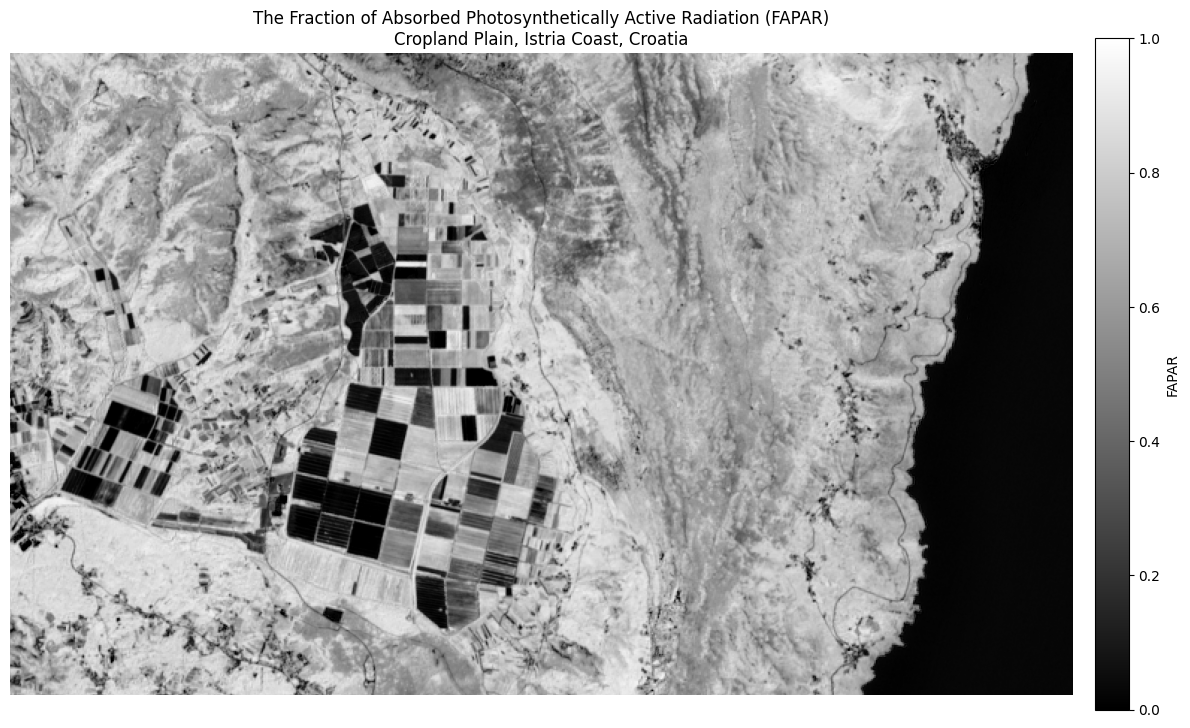

In [20]:
ds = rioxarray.open_rasterio(filename).squeeze()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(
    ds,
    extent=[ds.x.values.min(), ds.x.values.max(), ds.y.values.min(), ds.y.values.max()],
    cmap="gray",
    vmin=0,
    vmax=1,
)
plt.colorbar(im, ax=ax, label="FAPAR", fraction=0.03, pad=0.02)
ax.set_title(
    "The Fraction of Absorbed Photosynthetically Active Radiation (FAPAR)\n"
    f"{current_params['location_name']}",
    fontsize=12,
)
ax.axis("off")
plt.tight_layout()
plt.show()

## Interpretation Guide

### FAPAR Results:

**Darker pixels (near zero -> low FAPAR)**
- Bare soil, sand, urban surfaces, water
- Sparse or stressed vegetation with little leaf coverage
- Harvested or unused fields

**Lighter pixels (near one -> high FAPAR)**
- Dense, healthy vegetation such as mature forests, full-canopy crops, plantations
- High leaf area actively intercepting and absorbing sunlight for photosynthesis

**Mid-grey tones**
- Partial vegetation cover — grasslands, shrublands, early-season or low-density crops
- Mixed pixels containing both vegetated and non-vegetated surfaces

### Limitations:

- The neural network is ported from SNAP without input/output validation. Out-of-range reflectance values (clouds, shadows, water) are not flagged.
- The neural model was trained on specific vegetation types, results may be unreliable for surface types outside the training distribution (e.g. tropical forests, flooded vegetation).
- Reflectance scale factor is backend-specific (10000 for CDSE, 1.0 for EOPF) — using the wrong endpoint without the correct scale produces physically meaningless band values
- Not all openEO backends support all processes used (e.g. `tanh`, `pi`). Portability depends on backend process coverage

In [21]:
# Create a directory to export images, UDP, and OGC API records
from pathlib import Path

_repo_root = next(p for p in Path.cwd().parents if (p / "algorithm_registration").exists())
_alg_dir = _repo_root / "algorithm_registration" / _algorithm_id
_records_dir = _alg_dir / "records"
_udp_dir = _alg_dir / "openeo_udp"

_records_dir.mkdir(parents=True, exist_ok=True)
_udp_dir.mkdir(parents=True, exist_ok=True)

In [22]:
# Export the process graph for reuse
import json

process_graph = {
    "process_graph": fapar_image.flat_graph(),
    "parameters": [
        current_params["time"].to_dict(),
        current_params["bounding_box"].to_dict(),
        current_params["cloud_cover"].to_dict()
    ],
    "id": _algorithm_id,
    "summary": (
        "Calculation of Fraction of Absorbed Photosynthetically Active Radiation (FAPAR)"
        "using Sentinel-2 imagery with the OpenEO API"
    ),
    "description": (
        "Calculates the Fraction of Absorbed Photosynthetically Active Radiation (FAPAR) "
        "from Sentinel-2 L2A imagery using a neural network algorithm ported from SNAP. "
        "FAPAR is a dimensionless fraction (0–1) representing the proportion of incoming "
        "solar radiation in the 400–700 nm range absorbed by live green vegetation for "
        "photosynthesis. The neural network takes 8 spectral bands and 4 angular inputs "
        "(view and sun geometry) and applies the SNAP BVNet weights. "
        "Suitable for monitoring vegetation health, canopy development, and "
        "carbon flux estimation across croplands, forests, and natural ecosystems."
    )
}

# Save the process graph
with open(f"{_udp_dir}/{_algorithm_id}.json", "w") as f:
    json.dump(process_graph, f, indent=2)

print(f"Process graph exported to {_udp_dir}/{_algorithm_id}.json")
print(f"Process ID: {_algorithm_id}")

Process graph exported to /home/emathot/Workspace/DevelopmentSeed/openeo-udp/algorithm_registration/fapar/openeo_udp/fapar.json
Process ID: fapar


In [23]:
# Export necessary metadata to register the process graph in APEx Algorithm Catalogue 
if "_algorithm_id" not in globals():
    _algorithm_id = "fapar"

_repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "notebooks").exists())
_nb_href = f"{(Path.cwd() / 'fapar.ipynb').relative_to(_repo_root)}"
_alg_dir = _repo_root / "algorithm_registration" / _algorithm_id
_records_dir = _alg_dir / "records"

_records_dir.mkdir(parents=True, exist_ok=True)
# Notebook metadata
metadata = {
    "id" : _algorithm_id,
    "title" : "Fraction of Absorbed Photosynthetically Active Radiation (FAPAR)",
    "preview_title" : "FAPAR Calculation",
    "description" : (
        "Calculates the Fraction of Absorbed Photosynthetically Active Radiation (FAPAR) "
        "from Sentinel-2 L2A imagery using a neural network algorithm ported from SNAP. "
        "FAPAR is a dimensionless fraction (0–1) representing the proportion of incoming "
        "solar radiation in the 400–700 nm range absorbed by live green vegetation for "
        "photosynthesis. The neural network takes 8 spectral bands and 4 angular inputs "
        "(view and sun geometry) and applies the SNAP BVNet weights. "
        "Suitable for monitoring vegetation health, canopy development, and "
        "carbon flux estimation across croplands, forests, and natural ecosystems."
    ),
    "keywords" : ["Agriculture", "Vegetation", "Fraction of Absorbed Photosynthetic Active Radiation (fAPAR)", "Sentinel-2"],
    "themes" : ["VEGETATION", "REMOTE SENSING", "Sentinel-2 MSI"],
    "created" : "2026-06-03T00:00:00Z",
    "updated" : "2026-06-03T00:00:00Z",
    "license" : "CC-BY-SA-4.0",
    "openeo_backend_title" : "CDSE openEO Federation",
    "openeo_backend_url" : "https://openeofed.dataspace.copernicus.eu",
    "notebook_github_location" : _nb_href,
    "collection_id" : "SENTINEL2_L2A",
    "attribution" : {
        "original_script" : "https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/fapar/",
        "authors" : ["Authors not listed"],
        "source_repository" : "https://github.com/sentinel-hub/custom-scripts",
        "citation" : None
    }
}

## References and Attribution

**Original Script:** [FAPAR (The Fraction of Absorbed Photosynthetically Active Radiation)](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/fapar/)

**Author:** Authors not listed in the original Evalscript

**Source Repository:** [Sentinel Hub Custom Scripts](https://github.com/sentinel-hub/custom-scripts)

### OpenEO Conversion:
- **Conversion Date**: 3 June 2026
- **OpenEO Framework**: Adapted for openEO API and process graph structure
- **Backend Tested**: CDSE

## Conclusion

This notebook successfully demonstrates the conversion of the FAPAR algorithm to an OpenEO User-Defined Process. The implementation:

✅ **Maintains Scientific Accuracy**: Preserves the original algorithm's methodology

✅ **Provides Flexible Parameter Management**: Works with multiple locations, which are Cropland Plain, Istria Coast, Croatia and Natural Reserve in Rome, Italy

✅ **Follows OpenEO Standards**: Uses parameterized process graphs for reusability

✅ **Includes Comprehensive Documentation**: Provides interpretation guides and usage examples

### Key Achievements:

1. **Algorithm Implementation**: Successfully implemented FAPAR algorithm using OpenEO processes
2. **Parameter Management**: Integrated with the OpenEO UDP parameter system
3. **Multi-backend Support**: Works in the backends that provide viewing zenith & azimuth angles and sun zenith & azimuth angles
4. **Process Graph Export**: Generated reusable UDP definition

This conversion makes the FAPAR algorithm accessible to the broader OpenEO ecosystem while maintaining its scientific rigor and practical utility.